# LIDC Nodule Cubes — Analyse & Inspect

The data produced by `scripts/prepare_lidc.py`. Each nodule is a
**64 x 64 x 64** box of CT, resampled to 1 mm voxels, so 64 means 64 mm in
every direction. Values are raw Hounsfield units: about -1000 for air, 0 for
water, +40 for soft tissue, +1000 for bone.

One row of the table = one nodule = one cube file + its concepts + its label.

If you have no cubes yet:

```bash
python scripts/prepare_lidc.py --n-patients 50 --verbose
```


## 0. Run from the repo root

Paths below are relative to the repo root, but Jupyter starts in
`notebooks/`. This walks up until it finds the repo and `cd`s there,
so the notebook works wherever you launched it from.


In [14]:
# Work from the repo root no matter where Jupyter was launched from.
import os
from pathlib import Path

_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / "cbmc").is_dir() and (_p / "pyproject.toml").exists():
        os.chdir(_p)
        break
else:
    raise RuntimeError(
        f"Could not find the CBMC repo root above {_here}. "
        "Start Jupyter from inside the repo.")
print("working directory:", Path.cwd())



working directory: /Users/yassine/Desktop/CBMC/CBMC


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT  = Path("data/processed/lidc")
CUBES = ROOT / "cubes"

df = pd.read_csv(ROOT / "nodules.csv")
files = sorted(CUBES.glob("*.npy"))

print(f"cubes on disk : {len(files)}")
print(f"rows in table : {len(df)}")
print(f"patients      : {df.patient_id.nunique()}")
print(f"disk          : {sum(f.stat().st_size for f in files)/1e9:.2f} GB")

RATINGS = ["subtlety", "internalStructure", "calcification", "sphericity",
           "margin", "lobulation", "spiculation", "texture"]
CONTINUOUS = ["diameter", "volume", "surface_area"]

df.head(3)

cubes on disk : 2628
rows in table : 2628
patients      : 875
disk          : 1.38 GB


,file,patient_id,scan_idx,nodule_idx,n_annotations,subtlety,subtlety_std,internalStructure,internalStructure_std,calcification,...,spiculation,spiculation_std,texture,texture_std,malignancy,malignancy_std,label,diameter,volume,surface_area
0,LIDC-IDRI-0078_s0_00.npy,LIDC-IDRI-0078,0,0,4,4.50,0.500,1.0,0.0,6.0,...,2.25,1.0897,4.75,0.433,3.75,0.8292,1,23.9452,2516.3044,1193.4245
1,LIDC-IDRI-0078_s0_01.npy,LIDC-IDRI-0078,0,1,4,4.75,0.433,1.0,0.0,6.0,...,2.25,1.2990,4.50,0.500,3.75,0.8292,1,20.6944,2193.2503,1018.7490
2,LIDC-IDRI-0078_s0_02.npy,LIDC-IDRI-0078,0,2,1,4.00,0.000,1.0,0.0,5.0,...,1.00,0.0000,5.00,0.000,1.00,0.0000,0,5.0767,62.1075,66.9106


## 1. Windowing — why the raw numbers are unusable as an image

A cube spans roughly -1000 to +1000 HU, but everything interesting about a
nodule sits in a narrow part of that. Displaying the full range makes the
nodule invisible. The standard lung window clips to [-1000, 400].

shape (64, 64, 64)  dtype int16  range -1005 to 967 HU


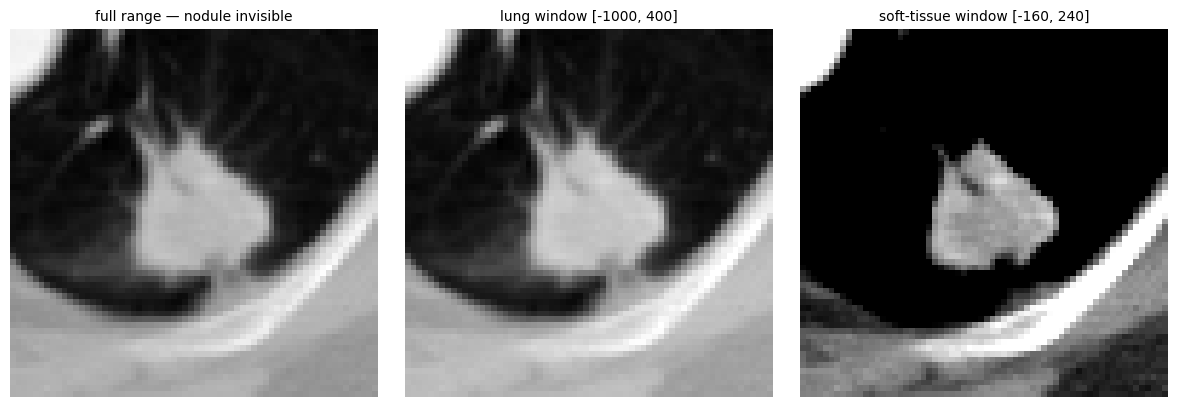

In [16]:
cube = np.load(files[0])
print(f"shape {cube.shape}  dtype {cube.dtype}  range {cube.min()} to {cube.max()} HU")

mid = cube[:, :, 32]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (lo, hi, title) in zip(axes, [
        (mid.min(), mid.max(), "full range — nodule invisible"),
        (-1000, 400, "lung window [-1000, 400]"),
        (-160, 240, "soft-tissue window [-160, 240]")]):
    ax.imshow(np.clip(mid, lo, hi), cmap="gray")
    ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

def show(ax, img, lo=-1000, hi=400):
    """Draw one slice in the lung window."""
    ax.imshow(np.clip(img, lo, hi), cmap="gray")
    ax.axis("off")

## 2. A nodule is 3D — three views of the same one

The cube is centred on the nodule, so slice 32 of each axis cuts through it.
Looking at all three is the quickest check that the crop is actually centred.

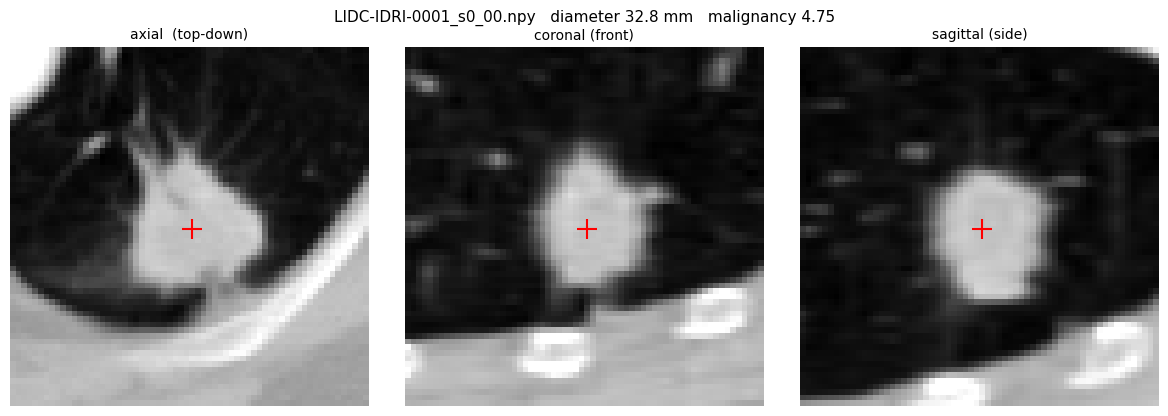

In [17]:
i = 0
cube = np.load(files[i])
row = df[df.file == files[i].name].iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, (plane, img) in zip(axes, [
        ("axial  (top-down)",  cube[:, :, 32]),
        ("coronal (front)",    cube[:, 32, :]),
        ("sagittal (side)",    cube[32, :, :])]):
    show(ax, img)
    ax.plot(32, 32, "r+", ms=14, mew=1.5)
    ax.set_title(plane, fontsize=10)
fig.suptitle(f"{row.file}   diameter {row.diameter:.1f} mm   "
             f"malignancy {row.malignancy:.2f}", fontsize=11)
plt.tight_layout(); plt.show()

## 3. Walking through the slices

A nodule spans several slices. Stepping through them shows it appear, grow and
disappear — which is the information a single 2D slice would throw away, and
the reason the shape concepts (sphericity, lobulation, spiculation) need 3D.

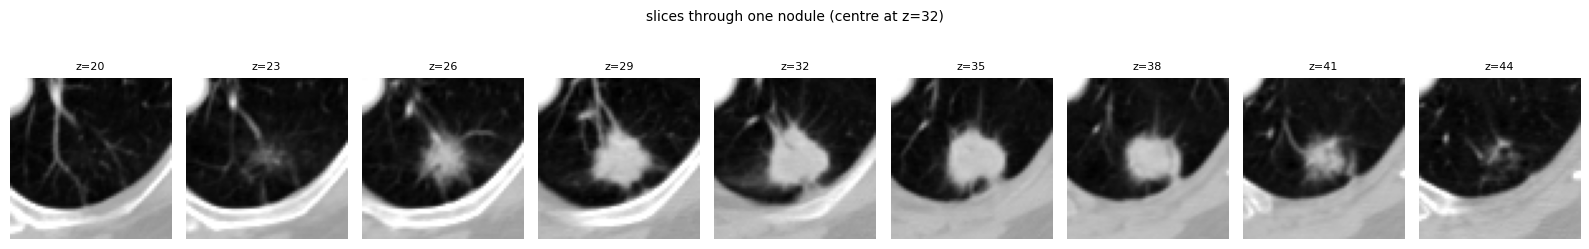

In [18]:
zs = range(20, 45, 3)
fig, axes = plt.subplots(1, len(list(zs)), figsize=(16, 2.4))
for ax, z in zip(axes, range(20, 45, 3)):
    show(ax, cube[:, :, z])
    ax.set_title(f"z={z}", fontsize=8)
plt.suptitle("slices through one nodule (centre at z=32)", y=1.06, fontsize=10)
plt.tight_layout(); plt.show()

## 4. A gallery — random nodules, middle slice

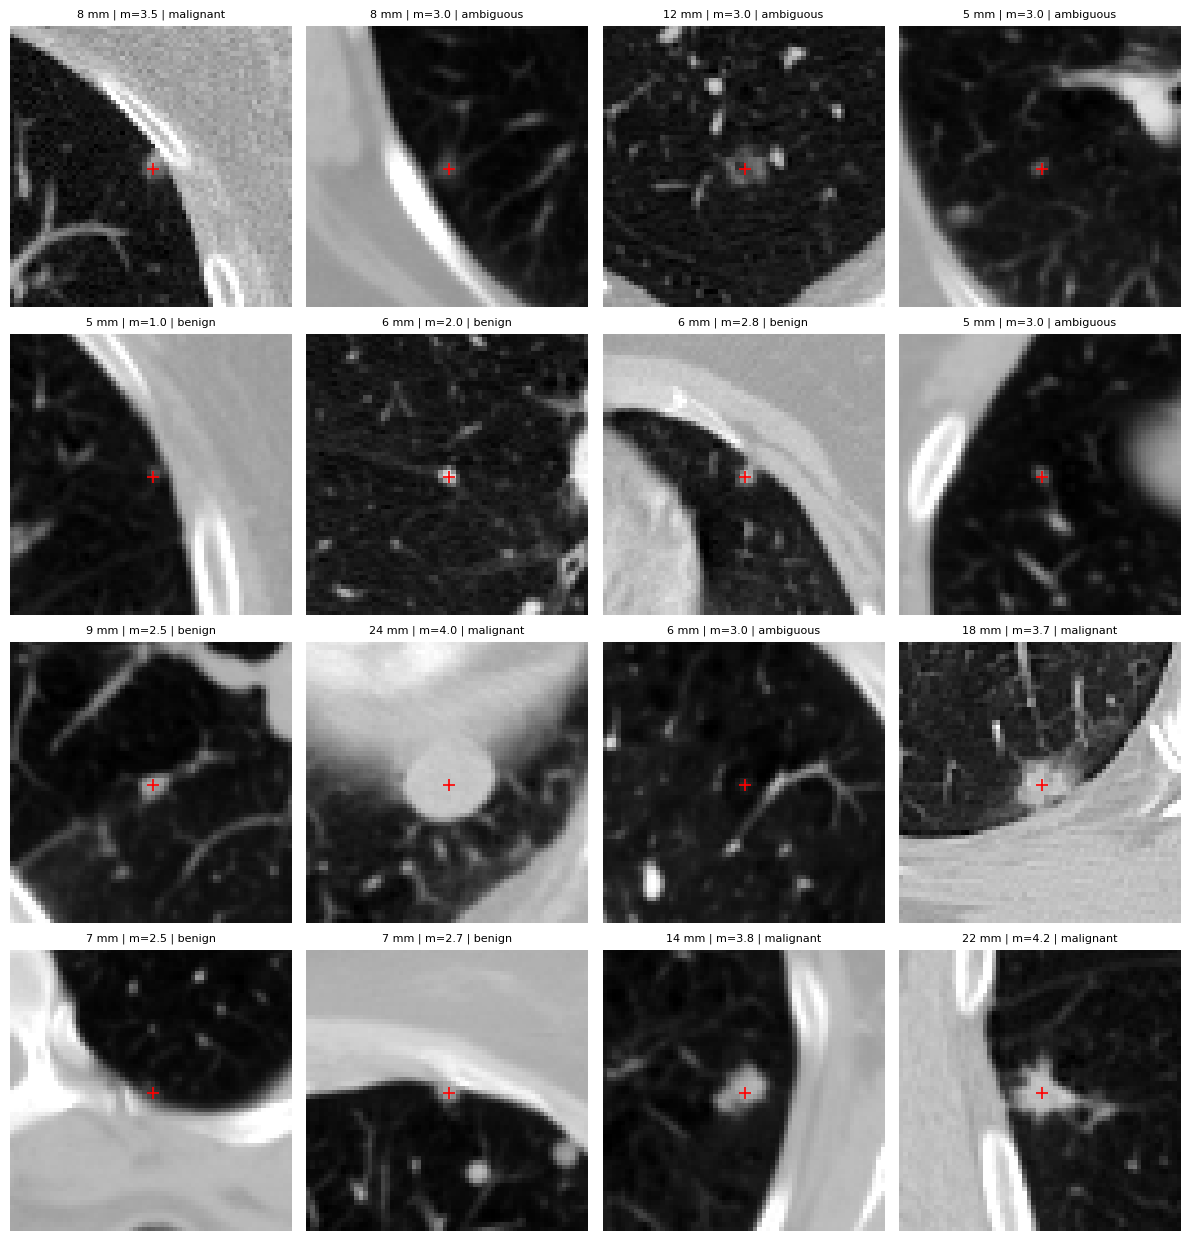

In [19]:
rng = np.random.default_rng(0)
pick = rng.choice(len(files), size=min(16, len(files)), replace=False)
info = df.set_index("file")

fig, axes = plt.subplots(4, 4, figsize=(12, 12.5))
for ax, idx in zip(axes.ravel(), pick):
    c = np.load(files[idx])
    r = info.loc[files[idx].name]
    show(ax, c[:, :, 32])
    ax.plot(32, 32, "r+", ms=9, mew=1.2)
    tag = {1: "malignant", 0: "benign", -1: "ambiguous"}[int(r.label)]
    ax.set_title(f"{r.diameter:.0f} mm | m={r.malignancy:.1f} | {tag}", fontsize=8)
plt.tight_layout(); plt.show()

## 5. Malignant vs benign, side by side

Malignant nodules tend to be larger with ragged, spiculated edges; benign ones
smaller and smoother. Whether that is visible to the eye is a good sanity check
on whether a model could learn it.

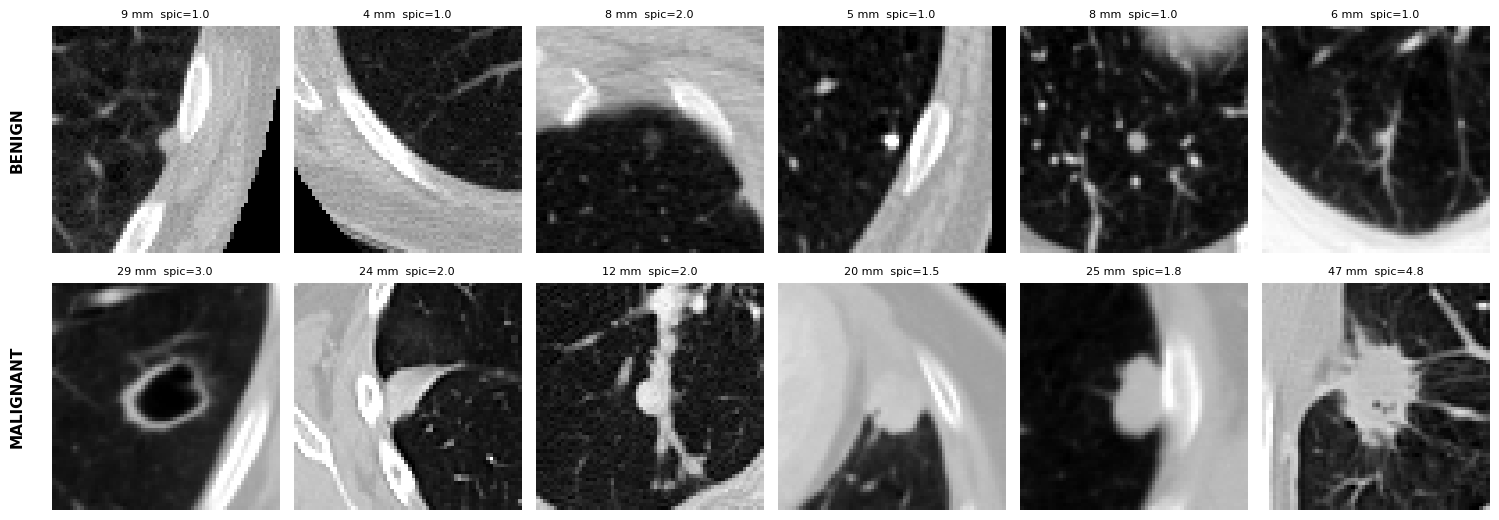

In [20]:
rng = np.random.default_rng(1)
fig, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for r_i, (lab, name) in enumerate([(0, "BENIGN"), (1, "MALIGNANT")]):
    sub = df[df.label == lab]
    sel = rng.choice(len(sub), size=6, replace=False)
    for c_i, s in enumerate(sel):
        r = sub.iloc[s]
        p = CUBES / r.file
        ax = axes[r_i, c_i]
        if p.exists():
            show(ax, np.load(p)[:, :, 32])
        ax.set_title(f"{r.diameter:.0f} mm  spic={r.spiculation:.1f}", fontsize=8)
        if c_i == 0:
            ax.text(-0.15, 0.5, name, transform=ax.transAxes, rotation=90,
                    va="center", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## 6. The labels

`malignancy` is a 1-5 rating averaged over radiologists, not a yes/no. The LIDC
convention binarises it: below 3 benign, above 3 malignant, exactly 3 ambiguous
and dropped.

label counts:
  -1  ambiguous (drop)     637  (24.2%)
   0  benign              1357  (51.6%)
   1  malignant            634  (24.1%)

usable: 1991  ->  68.2% benign / 31.8% malignant
with >=3 radiologists: 1180  ->  55.7% benign / 44.3% malignant


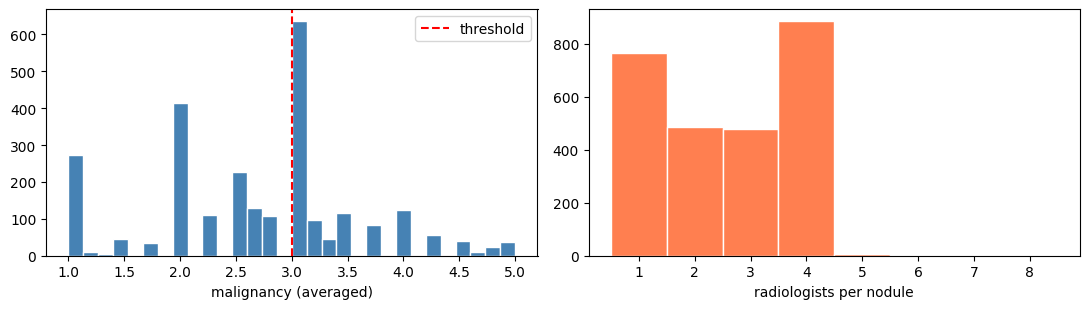

In [21]:
print("label counts:")
for v, n in df.label.value_counts().sort_index().items():
    name = {1: "malignant", 0: "benign", -1: "ambiguous (drop)"}[int(v)]
    print(f"  {int(v):>2}  {name:<18} {n:5d}  ({n/len(df):5.1%})")

usable = df[df.label != -1]
print(f"\nusable: {len(usable)}  ->  "
      f"{(usable.label==0).mean():.1%} benign / {(usable.label==1).mean():.1%} malignant")

strict = df[(df.n_annotations >= 3) & (df.label != -1)]
print(f"with >=3 radiologists: {len(strict)}  ->  "
      f"{(strict.label==0).mean():.1%} benign / {(strict.label==1).mean():.1%} malignant")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(df.malignancy, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(3, color="red", ls="--", label="threshold")
axes[0].set_xlabel("malignancy (averaged)"); axes[0].legend()
axes[1].hist(df.n_annotations, bins=range(1, 10), color="coral",
             edgecolor="white", align="left")
axes[1].set_xlabel("radiologists per nodule")
plt.tight_layout(); plt.show()

## 7. The concepts

Two kinds. The ratings are ordinal 1-5 (averaged, so fractional); the geometry
is genuinely continuous, in millimetres.

In [22]:
print("ORDINAL — radiologist ratings")
print(df[RATINGS].describe().loc[["min","max","mean","std"]].round(2).to_string())
print("\nCONTINUOUS — from the contour polygons")
print(df[CONTINUOUS].describe().loc[["min","max","mean","std"]].round(2).to_string())

print("\ncorrelation with malignancy:")
for n, c in df[RATINGS+CONTINUOUS].corrwith(df.malignancy).sort_values(
        key=abs, ascending=False).items():
    print(f"  {n:<20}{c:+.3f}  " + "#"*int(abs(c)*40))

ORDINAL — radiologist ratings
      subtlety  internalStructure  calcification  sphericity  margin  lobulation  spiculation  texture
min       1.00               1.00           2.50        1.00    1.00        1.00         1.00     1.00
max       5.00               5.00           6.00        5.00    5.00        5.00         5.00     5.00
mean      3.66               1.01           5.67        3.77    3.86        1.63         1.53     4.31
std       1.08               0.16           0.86        0.78    1.08        0.83         0.84     1.16

CONTINUOUS — from the contour polygons
      diameter    volume  surface_area
min       2.59      8.54         13.76
max      49.94  31112.20       9026.57
mean     10.15    626.18        373.67
std       6.72   1776.94        691.14

correlation with malignancy:
  calcification       +0.583  #######################
  diameter            +0.559  ######################
  surface_area        +0.469  ##################
  spiculation         +0.411  ####

Two of the "ratings" are **not ordinal** — `calcification` (1=popcorn,
2=laminated, 3=solid, 4=non-central, 5=central, 6=absent) and
`internalStructure` (1=soft tissue, 2=fluid, 3=fat, 4=air) are nominal codes.
Correlating them with malignancy is meaningless, and they should be modelled as
categorical concepts (Case 2), not continuous ones.

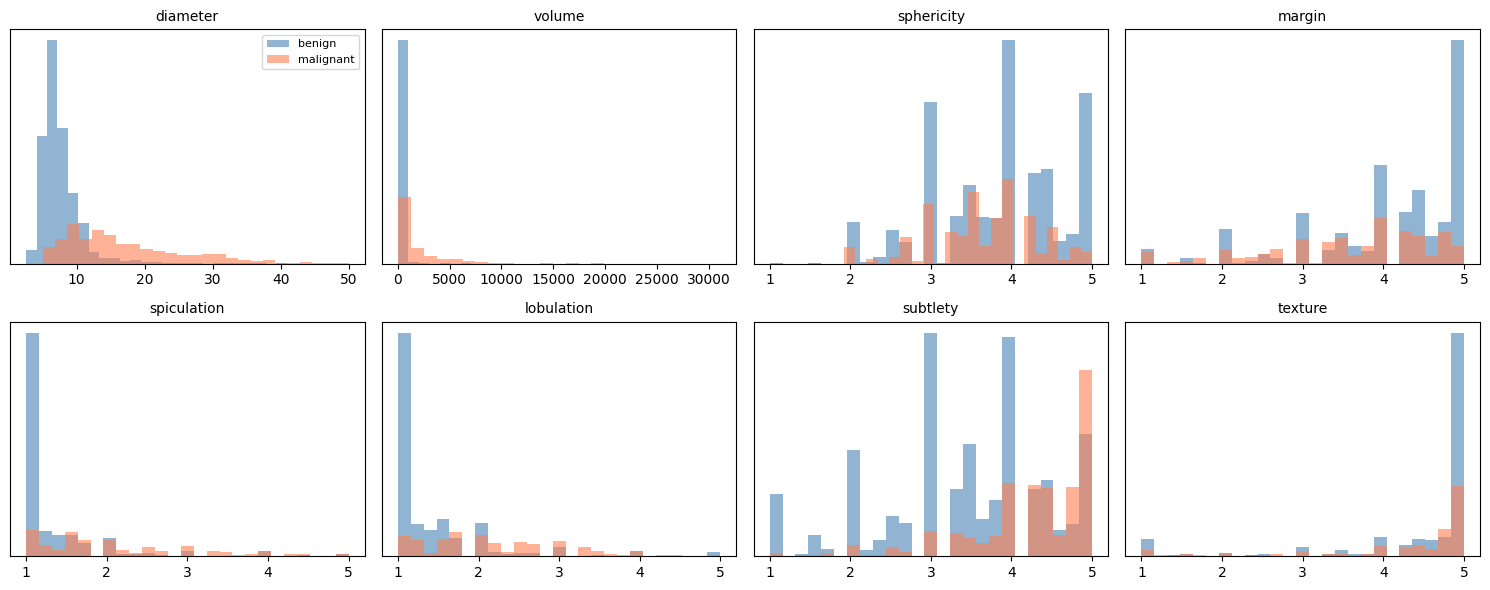

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, name in zip(axes.ravel(), ["diameter", "volume", "sphericity", "margin",
                                   "spiculation", "lobulation", "subtlety", "texture"]):
    for lab, col, nm in [(0, "steelblue", "benign"), (1, "coral", "malignant")]:
        ax.hist(df[df.label == lab][name], bins=25, alpha=0.6, color=col, label=nm)
    ax.set_title(name, fontsize=10); ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Radiologist disagreement

Every rating carries a `*_std` column: the spread across whoever annotated that
nodule. It is a free, human-derived uncertainty estimate, and the thing a
distributional concept model (Case 4) would try to reproduce.

In [24]:
multi = df[df.n_annotations >= 3]
print(f"nodules rated by >= 3 radiologists: {len(multi)}")
print(f"mean std of malignancy rating     : {multi.malignancy_std.mean():.3f}")
print(f"fully agreed                      : {(multi.malignancy_std == 0).sum()} "
      f"({(multi.malignancy_std == 0).mean():.1%})")

print("\nmean disagreement per concept:")
for r in RATINGS:
    print(f"  {r:<20}{multi[r+'_std'].mean():.3f}")

nodules rated by >= 3 radiologists: 1377
mean std of malignancy rating     : 0.639
fully agreed                      : 197 (14.3%)

mean disagreement per concept:
  subtlety            0.612
  internalStructure   0.015
  calcification       0.155
  sphericity          0.616
  margin              0.618
  lobulation          0.586
  spiculation         0.501
  texture             0.353


## 9. What a training batch looks like

The cube needs scaling before it reaches a network. Normalise with a **fixed**
window applied to every cube identically — never per-cube, which would destroy
the fact that HU are absolute physical units.

In [25]:
def to_tensor(cube, lo=-1000, hi=400):
    """HU cube -> float array in [0,1], same window for every sample."""
    x = np.clip(cube.astype(np.float32), lo, hi)
    return (x - lo) / (hi - lo)

c = np.load(files[0])
x = to_tensor(c)
print(f"raw   : {c.dtype}  {c.min():>6} .. {c.max():>5} HU")
print(f"scaled: {x.dtype}  {x.min():.3f} .. {x.max():.3f}")
print(f"\none sample -> input (1, 64, 64, 64), concepts (11,), label scalar")
print(f"memory per cube: {x.nbytes/1e6:.2f} MB as float32, "
      f"{c.nbytes/1e6:.2f} MB as int16 on disk")

raw   : int16   -1005 ..   967 HU
scaled: float32  0.000 .. 1.000

one sample -> input (1, 64, 64, 64), concepts (11,), label scalar
memory per cube: 1.05 MB as float32, 0.52 MB as int16 on disk


## Reminders for training

- **Split by `patient_id`, not by nodule.** 71% of nodules share a patient with
  another, and in 56% of those cases every sibling carries the same label. A
  random split leaks the scanner and the lung, not the disease.
- **Drop `label == -1`** — those are the nodules the radiologists split on.
- Consider `n_annotations >= 3`: fewer samples but much better class balance
  and more reliable labels.
- Augment with flips and rotations; nodules have no canonical orientation.


---
# Part 2 — The model and a training run

Everything above was inspection. Below is a complete, runnable pipeline:
dataset, patient-level split, 3D CNN + concept bottleneck, training loop and
test. Keep the epochs small here — this is to prove the pipeline works before
submitting it to the cluster, not to get a publishable number.

## 10. Dataset

One sample is `(cube, concepts, label)`, matching the convention the rest of
the repo uses.

Two concepts are dropped: `calcification` and `internalStructure` are nominal
codes (1=popcorn, 2=laminated, ...), not magnitudes, so treating them as
continuous is meaningless. They belong in the categorical block instead.

Concepts are **min-max scaled to [-1, 1]** using statistics from the TRAINING
split only, and the scaler keeps the inverse so concept error can be reported
in original units (mm, mm3, rating points).

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

CONCEPTS = ["subtlety", "sphericity", "margin", "lobulation", "spiculation",
            "texture", "diameter", "volume", "surface_area"]
HU_LO, HU_HI = -1000, 400          # lung window, applied identically to every cube


class MinMaxScaler:
    """Scale each concept to [-1, 1] and back. Fit on train only."""

    def __init__(self, frame):
        self.lo = frame[CONCEPTS].min().values.astype("float32")
        self.hi = frame[CONCEPTS].max().values.astype("float32")
        self.span = np.maximum(self.hi - self.lo, 1e-8)

    def forward(self, raw):                 # original units -> [-1, 1]
        return 2.0 * (raw - self.lo) / self.span - 1.0

    def inverse(self, z):                   # [-1, 1] -> original units
        return (z + 1.0) / 2.0 * self.span + self.lo


class LIDCNodules(Dataset):
    def __init__(self, frame, scaler, cubes_dir=CUBES):
        self.frame = frame.reset_index(drop=True)
        self.scaler = scaler
        self.dir = Path(cubes_dir)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        cube = np.load(self.dir / row.file).astype(np.float32)
        cube = (np.clip(cube, HU_LO, HU_HI) - HU_LO) / (HU_HI - HU_LO)   # -> [0,1]
        x = torch.from_numpy(cube).unsqueeze(0)                          # (1,64,64,64)
        c = torch.from_numpy(
            self.scaler.forward(row[CONCEPTS].values.astype("float32")))
        return x, c, torch.tensor(int(row.label), dtype=torch.long)


print(f"{len(CONCEPTS)} concepts: {CONCEPTS}")

9 concepts: ['subtlety', 'sphericity', 'margin', 'lobulation', 'spiculation', 'texture', 'diameter', 'volume', 'surface_area']


## 11. Split by patient, not by nodule

71% of nodules share a patient with another, and in 56% of those cases every
sibling carries the same label. Splitting by nodule would let the model
memorise the scanner and the lung rather than the disease.

In [27]:
from sklearn.model_selection import GroupShuffleSplit

MIN_ANNOTATORS = 3        # better balance and more reliable labels
data = df[(df.label != -1) & (df.n_annotations >= MIN_ANNOTATORS)].copy()
print(f"usable nodules: {len(data)} from {data.patient_id.nunique()} patients")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_i, te_i = next(gss.split(data, groups=data.patient_id))
train_df, test_df = data.iloc[tr_i], data.iloc[te_i]

overlap = set(train_df.patient_id) & set(test_df.patient_id)
print(f"train {len(train_df):4d} nodules / {train_df.patient_id.nunique():3d} patients"
      f"   malignant {train_df.label.mean():.1%}")
print(f"test  {len(test_df):4d} nodules / {test_df.patient_id.nunique():3d} patients"
      f"   malignant {test_df.label.mean():.1%}")
print(f"patients in both splits: {len(overlap)}   <- must be 0")
assert not overlap

scaler = MinMaxScaler(train_df)                     # fit on TRAIN only
for n, lo, hi in zip(CONCEPTS, scaler.lo, scaler.hi):
    print(f"  {n:<14} {lo:>8.2f} .. {hi:>9.2f}  ->  [-1, 1]")

usable nodules: 1180 from 638 patients
train  940 nodules / 510 patients   malignant 43.0%
test   240 nodules / 128 patients   malignant 49.6%
patients in both splits: 0   <- must be 0
  subtlety           1.00 ..      5.00  ->  [-1, 1]
  sphericity         2.00 ..      5.00  ->  [-1, 1]
  margin             1.00 ..      5.00  ->  [-1, 1]
  lobulation         1.00 ..      4.67  ->  [-1, 1]
  spiculation        1.00 ..      5.00  ->  [-1, 1]
  texture            1.00 ..      5.00  ->  [-1, 1]
  diameter           4.52 ..     44.94  ->  [-1, 1]
  volume            26.68 ..  18746.76  ->  [-1, 1]
  surface_area      39.54 ..   5391.13  ->  [-1, 1]


## 12. The model

A small 3D CNN encoder, then the continuous concept bottleneck (Case 3.5) from
`cbmc.concepts`, then a 2-class head. Swap `CEM` for `CEMCategorical` to run
the categorical variant instead — the interface is identical.

In [28]:
from cbmc.concepts import CEM


class Conv3DEncoder(nn.Module):
    """(1,64,64,64) -> (out_dim,). Four stride-2 blocks then global average pool."""

    def __init__(self, channels=(16, 32, 64, 128)):
        super().__init__()
        layers, in_ch = [], 1
        for ch in channels:
            layers += [nn.Conv3d(in_ch, ch, 3, padding=1),
                       nn.BatchNorm3d(ch), nn.ReLU(inplace=True),
                       nn.MaxPool3d(2)]
            in_ch = ch
        layers += [nn.AdaptiveAvgPool3d(1), nn.Flatten()]
        self.net = nn.Sequential(*layers)
        self.out_dim = channels[-1]

    def forward(self, x):
        return self.net(x)


class NoduleCBM(nn.Module):
    def __init__(self, n_concepts, n_classes=2, embedding_dim=16):
        super().__init__()
        self.encoder = Conv3DEncoder()
        self.cem = CEM(input_dim=self.encoder.out_dim, n_concepts=n_concepts,
                       embedding_dim=embedding_dim, hidden_dim=64,
                       depth=2, dropout=0.1)
        self.head = nn.Linear(self.cem.output_dim, n_classes)

    def forward(self, x, interventions=None, mask=None):
        h = self.encoder(x)
        emb, concepts = self.cem(h, interventions, mask)
        return self.head(emb), concepts


device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
model = NoduleCBM(len(CONCEPTS)).to(device)
n_par = sum(p.numel() for p in model.parameters())
print(f"device: {device}")
print(f"parameters: {n_par:,}  ({n_par*4/1e6:.1f} MB)")
with torch.no_grad():
    y, c = model(torch.zeros(2, 1, 64, 64, 64, device=device))
print(f"forward check: logits {tuple(y.shape)}, concepts {tuple(c.shape)}")

device: mps
parameters: 591,275  (2.4 MB)
forward check: logits (2, 2), concepts (2, 9)


## 13. Training loop

Two losses: cross-entropy on malignancy and MSE on the concepts.

`CONCEPT_WEIGHT` matters. Here the task loss is a cross-entropy (order 0.7) and
the concept loss an MSE in [-1,1] (order 0.3), so they are already comparable
and 1.0 is reasonable — unlike ArithmeticMNIST, where the task MSE spanned
0-81 and swamped the concept term 95:1. Check the printed losses: if the
concept term is far smaller, raise this.

`INTERVENTION_PROB` trains some batches with ground-truth concepts, so a
test-time intervention is not out-of-distribution.

In [30]:
EPOCHS            = 100        # small: this is a pipeline test
BATCH_SIZE        = 16
LR                = 1e-3
CONCEPT_WEIGHT    = 1.0
INTERVENTION_PROB = 0.25

train_loader = DataLoader(LIDCNodules(train_df, scaler), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)
test_loader  = DataLoader(LIDCNodules(test_df, scaler), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

model = NoduleCBM(len(CONCEPTS)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
task_crit = nn.CrossEntropyLoss()

import time, random
for ep in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    tot_task = tot_concept = correct = seen = 0
    for x, c, y in train_loader:
        x, c, y = x.to(device), c.to(device), y.to(device)
        interv = c if random.random() < INTERVENTION_PROB else None
        logits, concepts = model(x, interventions=interv)

        l_task = task_crit(logits, y)
        l_conc = F.mse_loss(concepts, c)
        loss = l_task + CONCEPT_WEIGHT * l_conc

        opt.zero_grad(); loss.backward(); opt.step()
        tot_task += l_task.item() * y.size(0)
        tot_concept += l_conc.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        seen += y.size(0)

    print(f"epoch {ep}/{EPOCHS}  task {tot_task/seen:.4f}  concept {tot_concept/seen:.4f}"
          f"  train acc {correct/seen:.3f}  ({time.time()-t0:.0f}s)", flush=True)

epoch 1/100  task 0.6814  concept 0.2459  train acc 0.591  (30s)
epoch 2/100  task 0.6794  concept 0.1549  train acc 0.585  (29s)
epoch 3/100  task 0.6530  concept 0.1520  train acc 0.585  (29s)
epoch 4/100  task 0.6238  concept 0.1567  train acc 0.647  (29s)
epoch 5/100  task 0.6273  concept 0.1530  train acc 0.627  (30s)
epoch 6/100  task 0.5995  concept 0.1538  train acc 0.648  (29s)
epoch 7/100  task 0.6231  concept 0.1520  train acc 0.633  (31s)
epoch 8/100  task 0.6165  concept 0.1508  train acc 0.646  (31s)
epoch 9/100  task 0.5992  concept 0.1497  train acc 0.665  (31s)
epoch 10/100  task 0.6048  concept 0.1489  train acc 0.645  (30s)
epoch 11/100  task 0.5859  concept 0.1500  train acc 0.680  (30s)
epoch 12/100  task 0.5847  concept 0.1486  train acc 0.683  (30s)
epoch 13/100  task 0.6147  concept 0.1480  train acc 0.648  (30s)
epoch 14/100  task 0.5856  concept 0.1477  train acc 0.681  (29s)
epoch 15/100  task 0.5998  concept 0.1461  train acc 0.661  (29s)
epoch 16/100  task 

KeyboardInterrupt: 

## 14. Test

Accuracy and balanced accuracy on the task; concept error reported in
**original units** by inverting the scaler, so "diameter is off by 2.3 mm" is
readable rather than "0.08 in normalised space".

Intervention accuracy is the interpretability number: feed the true concepts
and see whether the prediction improves.

In [31]:
@torch.no_grad()
def test(model, loader):
    model.eval()
    logit_all, y_all, c_pred, c_true, logit_int = [], [], [], [], []
    for x, c, y in loader:
        x, c, y = x.to(device), c.to(device), y.to(device)
        lg, cp = model(x)
        li, _  = model(x, interventions=c)          # full intervention
        logit_all.append(lg.cpu()); y_all.append(y.cpu())
        c_pred.append(cp.cpu()); c_true.append(c.cpu()); logit_int.append(li.cpu())

    lg = torch.cat(logit_all); y = torch.cat(y_all)
    li = torch.cat(logit_int)
    cp = torch.cat(c_pred).numpy(); ct = torch.cat(c_true).numpy()

    pred = lg.argmax(1)
    acc  = (pred == y).float().mean().item()
    bal  = np.mean([ (pred[y==k] == k).float().mean().item() for k in (0,1) ])
    acc_i = (li.argmax(1) == y).float().mean().item()

    # concept error in ORIGINAL units
    cp_raw, ct_raw = scaler.inverse(cp), scaler.inverse(ct)
    mae = np.abs(cp_raw - ct_raw).mean(0)
    mse = ((cp_raw - ct_raw) ** 2).mean(0)

    print(f"task accuracy            {acc:.3f}")
    print(f"balanced accuracy        {bal:.3f}   (chance 0.500)")
    print(f"accuracy w/ intervention {acc_i:.3f}")
    print(f"\nconfusion (rows true, cols pred):")
    for k in (0, 1):
        r = [(pred[(y==k)] == j).sum().item() for j in (0,1)]
        print(f"  {'benign   ' if k==0 else 'malignant'} {r}")
    print(f"\nconcept error in original units:")
    print(f"  {'concept':<16}{'MAE':>10}{'RMSE':>10}   units")
    for i, n in enumerate(CONCEPTS):
        u = "mm" if n == "diameter" else ("mm3" if n == "volume" else
            ("mm2" if n == "surface_area" else "rating"))
        print(f"  {n:<16}{mae[i]:>10.3f}{np.sqrt(mse[i]):>10.3f}   {u}")
    return acc, bal, acc_i

_ = test(model, test_loader)

task accuracy            0.771
balanced accuracy        0.769   (chance 0.500)
accuracy w/ intervention 0.854

confusion (rows true, cols pred):
  benign    [115, 6]
  malignant [49, 70]

concept error in original units:
  concept                MAE      RMSE   units
  subtlety             0.618     0.777   rating
  sphericity           0.488     0.579   rating
  margin               0.658     0.826   rating
  lobulation           0.513     0.660   rating
  spiculation          0.577     0.700   rating
  texture              0.627     0.956   rating
  diameter             3.939     6.259   mm
  volume             985.165  1975.482   mm3
  surface_area       483.772   674.950   mm2


## 15. Before the cluster

If the numbers above are near chance that is expected at 5 epochs — the point
is that the pipeline runs end to end. What to check:

- loss decreasing each epoch
- `patients in both splits: 0`
- concept MAE smaller than just predicting the mean
- intervention accuracy at least as good as plain accuracy (if it is worse,
  raise `INTERVENTION_PROB`)

Then scale up: more epochs, several seeds, and the ablations
(`CEMCategorical`, `CEMLinear`, a no-bottleneck baseline). Mirror
`run_binned.sh` for the cluster version.